In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore', module='matplotlib')

import specfit

In [ ]:
# Load and process spectrum data
data = np.loadtxt('spectra/example_spectrum_A.txt', skiprows=1)
obs_wave = data[:, 0]
obs_flux = data[:, 1] 
em_lines_all = data[:, 2]

# Normalize flux and extract valid emission lines
norm = 1e-19
obs_flux = obs_flux / norm
obs_em_lines_wave = em_lines_all[~np.isnan(em_lines_all)]

# Filter data to good wavelength ranges
good_ranges = [(1.013e4, 1.283e4), (1.330e4, 1.671e4), (1.751e4, 2.226e4)]
wave_filter, flux_filter = specfit.ranges_filter(obs_wave, obs_flux, ranges=good_ranges)

All emission lines = [10656.36 13902.66 14182.74 14320.02 18770.18]


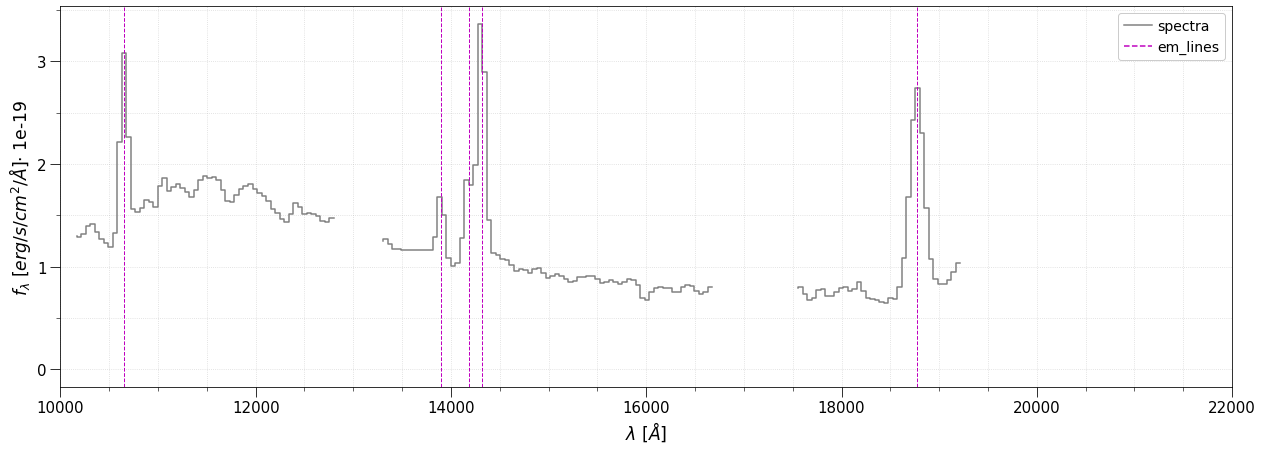

Emission line(s) in zoom = [14182.74 14320.02]


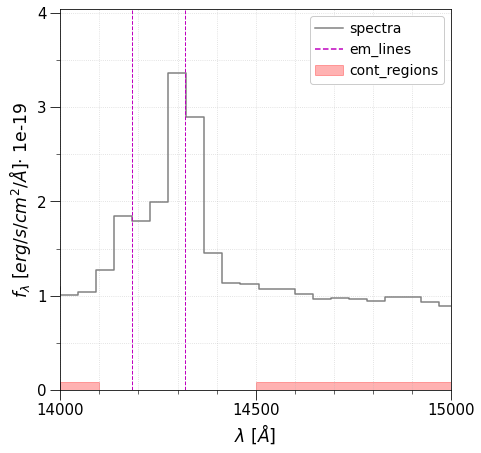

In [3]:
# Define zoom and continuum ranges
zoom_range = [(1.4e4, 1.5e4)]
cont_range = [(1.4e4, 1.41e4), (1.45e4, 1.5e4)]
zoom_min, zoom_max = zoom_range[0]

# Plot entire spectrum
print(f'All emission lines = {obs_em_lines_wave}')
specfit.plot_spectrum(wave_filter, flux_filter, obs_em_lines_wave, norm)

# Plot zoomed spectrum with continuum shading
mask = (wave_filter >= zoom_min) & (wave_filter <= zoom_max)
em_lines_in_range = obs_em_lines_wave[(obs_em_lines_wave >= zoom_min) & (obs_em_lines_wave <= zoom_max)]
wave_zoom = np.array(wave_filter[mask])
flux_zoom = np.array(flux_filter[mask])

print(f'Emission line(s) in zoom = {em_lines_in_range}')
specfit.plot_spectrum(wave_filter, flux_filter, obs_em_lines_wave, norm, 
                     zoom=zoom_range, cont=cont_range)

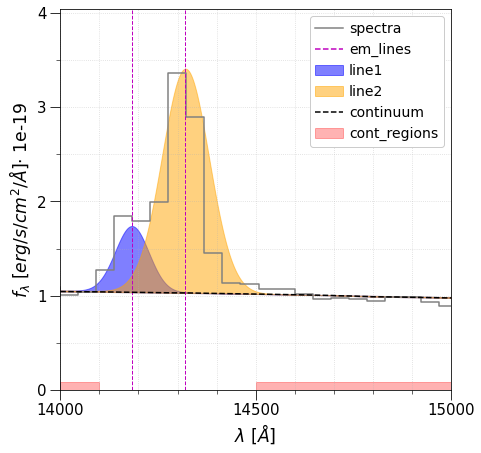

In [4]:
# Parameters
line_1, line_2 = 'line1', 'line2'
center_wave_1, center_wave_2 = 14182.74, 14320.02
n_iter = 1e3

# Automatic doublet detection and fitting
is_doublet = bool(line_1 and line_2 and center_wave_2)
result = specfit.em_line_fit(wave_zoom, flux_zoom, center_wave_1, center_wave_2, 
                            line_1, line_2, cont_range, zoom_range[0], n_iter)

# Unpack results based on doublet status
if is_doublet:
    continuum, xx_fit, fit1, fit2 = result
    fits = [fit1, fit2]
    labels = [line_1, line_2]
    colors = ['blue', 'orange']
else:
    continuum, xx_fit, fit1 = result
    fits = [fit1]
    labels = [line_1]
    colors = ['orange']

# Calculate integrated flux (using first fit)
integrated_flux, integrated_flux_error = specfit.calculate_line_flux(xx_fit, fit1, continuum, norm)

# Plot fitted spectrum
specfit.plot_fitted_spectrum(wave_filter, flux_filter, obs_em_lines_wave, norm, 
                           zoom_range, cont_range, xx_fit, continuum, 
                           fits, labels, colors)